# GSK_HepG2 ablation: metric vs training-data fraction

Pulls the single run from the `ablation_gsk_hepg2` wandb project, recovers the per-(fraction, model) rows from its history, and plots one line per model.

Each `wandb.log(row)` call in the ablation became a separate history step, so we read the full history with `scan_history()` and pivot on the `model` column ourselves.

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = "ablation"
RUN_PREFIX = "gsk_hepg2_data_fraction"
RUN_NAME = None  # set to an exact run name to pin a specific run; otherwise use the latest
METRIC = "test_average_precision"  # swap for test_mcc, test_f1, test_roc_auc, ...

api = wandb.Api()
runs = api.runs(f"{api.default_entity}/{PROJECT}")
if RUN_NAME is not None:
    run = next(r for r in runs if r.name == RUN_NAME)
else:
    # Runs are named '<prefix>_<timestamp>'; pick the most recent matching run.
    matches = [r for r in runs if r.name.startswith(RUN_PREFIX)]
    run = max(matches, key=lambda r: r.created_at)
run.name, run.id

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/rahul/.netrc.


('gsk_hepg2_data_fraction_20260620_211221', 'ppu55gq7')

In [2]:
# Full, unsampled history -> one row per (fraction, model, seed).
df = pd.DataFrame(run.scan_history())
df = df[["fraction", "seed", "model", "n_train", METRIC]].sort_values(
    ["model", "fraction", "seed"]
)
df

,fraction,seed,model,n_train,test_average_precision
0,0.1,42,chemprop,1054,0.203054
20,0.1,123,chemprop,1055,0.245762
2,0.2,42,chemprop,2111,0.222756
4,0.3,42,chemprop,3166,0.129125
6,0.4,42,chemprop,4222,0.344592
8,0.5,42,chemprop,5276,0.404026
10,0.6,42,chemprop,6332,0.375819
12,0.7,42,chemprop,7382,0.372740
14,0.8,42,chemprop,8434,0.338831
16,0.9,42,chemprop,9494,0.369318


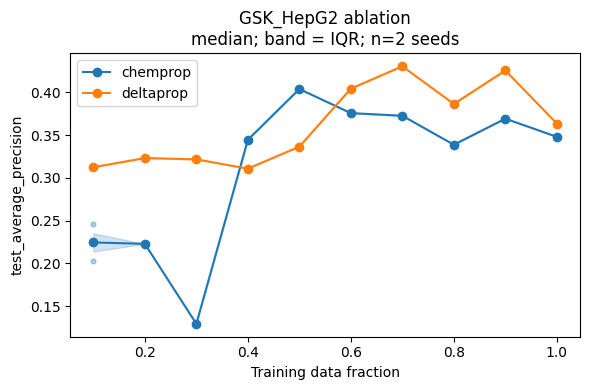

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

n_seeds = df["seed"].nunique()

# Aggregate across seeds: median as a line, IQR (Q1-Q3) as a shaded band, one per model.
# Average precision is mildly right-skewed across seeds (a single strong seed pulls the
# mean up), so we summarize with the median and overlay the raw per-seed points.
for model, g in df.groupby("model"):
    agg = (
        g.groupby("fraction")[METRIC]
        .agg(
            median="median",
            q1=lambda s: s.quantile(0.25),
            q3=lambda s: s.quantile(0.75),
        )
        .reset_index()
        .sort_values("fraction")
    )
    (line,) = ax.plot(
        agg["fraction"],
        agg["median"],
        marker="o",
        label=model,
    )
    color = line.get_color()
    ax.fill_between(
        agg["fraction"],
        agg["q1"],
        agg["q3"],
        color=color,
        alpha=0.2,
    )
    # Raw per-seed points, so the spread (and any single strong seed) stays visible.
    ax.scatter(
        g["fraction"],
        g[METRIC],
        color=color,
        s=12,
        alpha=0.35,
        zorder=3,
    )

ax.set_xlabel("Training data fraction")
ax.set_ylabel(METRIC)
ax.set_title(f"GSK_HepG2 ablation\nmedian; band = IQR; n={n_seeds} seeds")
ax.legend()
fig.tight_layout()
# fig.savefig("gsk_hepg2_ablation.png", dpi=150)
plt.show()